## Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pyarrow.parquet as pq
import pyarrow as pa
import pyarrow.compute as pc
from adam_core.time import Timestamp
from astropy.time import Time
import matplotlib.pyplot as plt
import quivr as qv
import numpy as np
import pickle
import requests
import scipy
import scipy.stats
from typing import Dict, Tuple, Optional
from adam_core.orbits.query.horizons import cache_or_query_rotational_period_inputs, RotationalPeriodInput
from adam_core.rotational_period.tests.paper_data import PAPER_TABLE2
from adam_core.rotational_period.types import FourierFitResult, FourierFullResult
from adam_core.rotational_period.high_order_fourier import run_complete_fourier

/workspaces/adam_core/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-30 02:28:59,475	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [3]:
ROTATIONAL_PERIOD_INPUTS_CACHE = "../data/rot_period_inputs.parquet"

## Read pre-pulled data for observations

In [4]:
all_data = pq.read_table("../data/paper_data.parquet")
all_data = all_data.sort_by("obstime")

In [5]:
def subset_data(object_id: str, data: pa.Table, quiet: bool = False) -> Tuple[pa.Table, pa.DoubleArray, Dict[str, pa.DoubleArray], Dict[str, pa.DoubleArray]]:
    """Pulls data for the given object from the collection of all data
    
    Returns:
    --------
    obs_time: DoubleArray
      All observation times for the given object as MJD, sorted ascending
    otime: dict[str, Timestamp]
      Dictionary from band color to timestamps for it
    mag: dict[str, DoubleArray]
      Dictionary from band color to magnitudes for it
    """
    selection = data.filter(pc.equal(data["provid"], object_id))
    obs_time = Timestamp.from_astropy(Time(selection["obstime"].to_pylist())).mjd()
    arc_len = pc.max(obs_time).as_py() - pc.min(obs_time).as_py()
    mag = {}
    otime = {}
    # TODO: And see other 'spellings' of same 4 colors
    for color in ["g", "i", "r", "u"]:
        color_lines = selection.filter(pc.equal(selection["band"], color))
        if len(color_lines) > 0:
          mag[color] = color_lines["mag"].cast('float')
          otime[color] = Timestamp.from_astropy(Time(color_lines["obstime"]))
    mean_mag_r = pc.mean(mag["r"])
    delta_mag_r = pc.max(mag["r"]).as_py() - pc.min(mag["r"]).as_py()
    if not quiet:
      print(f"For object {object_id}: num obs {len(selection)}, arc length {arc_len}")
      print(f"Mean mag in r-band {mean_mag_r}, delta mag in r-band {delta_mag_r}")
      print(f"Counts per band: g {len(mag['g'])}, i {len(mag['i'])}, r {len(mag['r'])}, u {len(mag.get('u', []))}")
    assert np.sum([len(v) for v in mag.values()]) == len(selection), f"Add missing colors, object {object_id}: {pc.unique(selection['band'])}"
    return selection, obs_time, otime, mag

## Sanity check for the data
Repro Figure 8 from the paper to see if our data input makes sense

In [6]:
# Pick an object from the paper "2025 MM81"
# should have mag variation 1.2, period 0.045 days ~= 1.1h
# from page 11 of the paper for 2025MM81:
# H mag = 21.1, mean mag r-band = 22.90, num obs=390, arc (days) 9,
# period (LSM/Furier) 1.1/1.1,
# Amplitude LSM/Furier 1.0/1.2, g-r LSM/Furier 0.55/0.53, g-i LSM/Furier 0.67/0.66,
# r-i LSM/Furier 0.12/0.12, axial elongation 2.1
mm81_id = "2025 MM81"
mm81_selection, mm81_obstime, mm81_otime, mm81_mag = subset_data(mm81_id, all_data)

For object 2025 MM81: num obs 390, arc length 9.035824999999022
Mean mag in r-band 22.902367843978706, delta mag in r-band 1.4479999542236328
Counts per band: g 127, i 89, r 174, u 0


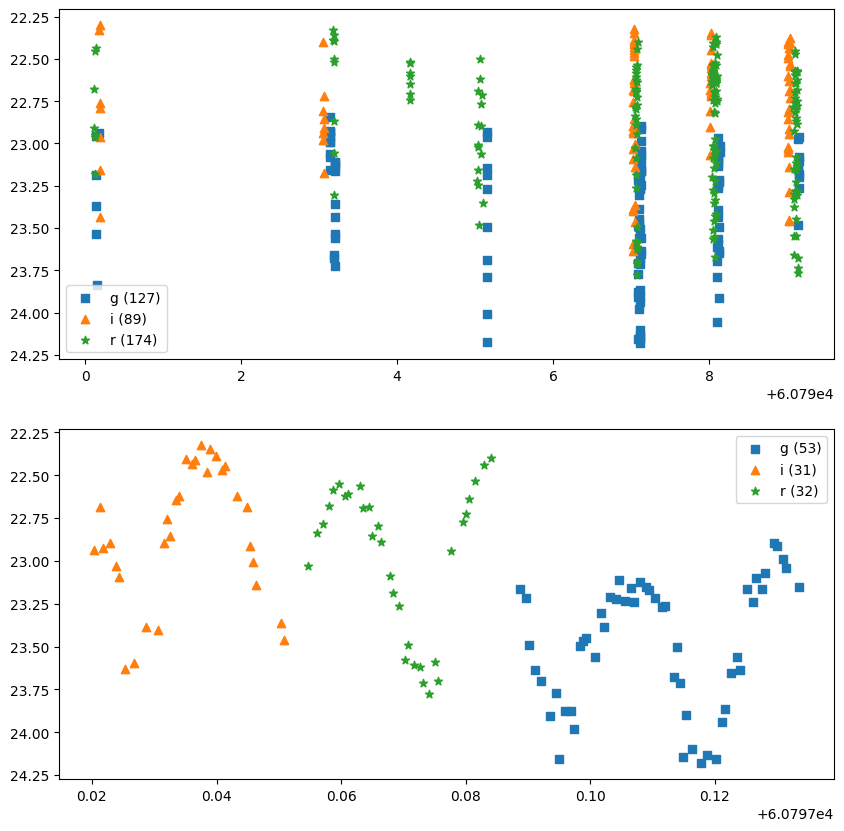

In [7]:
# Repro Figure 8 from the paper
def show_figure8(obs_time, otime, mag, first_day: float):
    """Draw figure similar to Figure8 in the paper.
    Parameters:
    -----------
    obs_time:
      sorted list of all observation times for the given object

    """
    # print(pc.min(otime["g"].mjd()), pc.max(otime["g"].mjd()))
    _fig, axs = plt.subplots(2, 1, figsize=(10, 10))
    axs[0].scatter(otime["g"].mjd().to_pylist(), mag["g"].to_pylist(), marker="s", c="tab:blue", label=f"g ({len(mag['g'])})")
    axs[0].scatter(otime["i"].mjd().to_pylist(), mag["i"].to_pylist(), marker="^", c="tab:orange", label=f"i ({len(mag['i'])})")
    axs[0].scatter(otime["r"].mjd().to_pylist(), mag["r"].to_pylist(), marker="*", c="tab:green", label=f"r ({len(mag['r'])})")
    axs[0].legend()
    axs[0].invert_yaxis()

    # Find the night with the observation count matching Figure 8 in the paper
    beginning_of_time = pc.min(obs_time).as_py() - 0.25
    start_time = beginning_of_time + first_day # 6 is the number that matched the count
    end_time = start_time + 1.5 # make sure to get the whole night

    selected_times = {}
    selected_mags = {}
    for color in ["g", "i", "r"]:
        index = pc.and_(pc.greater(otime[color].mjd(), start_time), pc.less(otime[color].mjd(), end_time))
        selected_times[color] = otime[color].mjd().to_numpy()[index]
        selected_mags[color] = mag[color].to_numpy()[index]
    axs[1].scatter(selected_times["g"], selected_mags["g"], marker="s", c="tab:blue", label=f"g ({len(selected_mags['g'])})")
    axs[1].scatter(selected_times["i"], selected_mags["i"], marker="^", c="tab:orange", label=f"i ({len(selected_mags['i'])})")
    axs[1].scatter(selected_times["r"], selected_mags["r"], marker="*", c="tab:green", label=f"r ({len(selected_mags['r'])})")
    axs[1].legend()
    axs[1].invert_yaxis()

    plt.show()

show_figure8(mm81_obstime, mm81_otime, mm81_mag, 6)

## High-order Fourier Analysis

In [8]:
def run_complete_fourier_with_cache(object_id: str, 
                                    kind: Optional[int],
                                    cache_file: str = "../data/fourier_outputs.parquet",
                                    force_query: bool = False) -> FourierFullResult:
    try:
        output_data = FourierFullResult.from_parquet(cache_file)
        print(f"Read total {len(output_data)} records")
    except:
        print(f"Failed to read {cache_file}")
        output_data = FourierFullResult.empty()
    result = output_data.apply_mask(pc.equal(output_data.object_id, object_id))
    if force_query or len(result) == 0:
        print(f"Recomputing Fourier for object {object_id}")
        selection, obstime, _otime, _mag = subset_data(object_id, all_data)
        inputs = cache_or_query_rotational_period_inputs(object_id, "X05", obstime, ROTATIONAL_PERIOD_INPUTS_CACHE)
        result = run_complete_fourier(object_id, selection, obstime, inputs, kind)
        output_data = qv.concatenate([
            output_data.apply_mask(pc.not_equal(output_data.object_id, object_id)),
            result,
            ])
        output_data.to_parquet(cache_file)
    return result
   

## Viz functions that may be occasionally helpful

In [9]:
def viz_vs_data(id, day, inputs, id_fit):
    k, sigma2, freq, values, size = id_fit
    fig, ax = plt.subplots(1,1, figsize=(10, 5))
    id_selection, id_obstime, id_otime, id_mag = subset_data(id, all_data)
    id_obstime = id_obstime.to_numpy()
    mag = id_selection["mag"].cast('float').to_numpy()
    start_time = np.min(id_obstime) - 0.25
    if day is not None:
        start_time += day
        index = (id_obstime > start_time) & (id_obstime < (start_time+1))
    else:
        index = np.array([True] * len(id_obstime))

    alpha = np.deg2rad(inputs.angle)[0]
    alpha_corr = values[0]*alpha + values[1]*alpha*alpha
    helio_r = inputs.sun_range.to_numpy()[0]
    topo_delta = inputs.obs_range.to_numpy()[0]
    mag_corr = 5*np.log10(helio_r * topo_delta)


    times = id_obstime[index] # np.linspace(np.min(id_obstime[index]), np.max(id_obstime[index]), num=100)
    base = 2*np.pi*freq*times
    G = np.zeros((len(times)))
    assert len(values) == 2+k*2+4
    for j in range(0, k):
        arg = base * (j+1)
        G += values[2+2*j]*np.cos(arg)
        G += values[2+2*j+1]*np.sin(arg)
        # print(f"A{j} -> {2+2*j}")
    H_g = values[2+2*k]
    H_i = values[2+2*k+1]
    H_r = values[2+2*k+2]
    G += H_r + alpha_corr + mag_corr
    print(f"Corrections alpha={alpha_corr} mag={mag_corr} ampl={np.max(G)-np.min(G)}")

    # index = range(100, 200)
    ax.scatter(id_obstime[index], mag[index])
    ax.plot(times, G, color="r")
    ax.yaxis_inverted()
    fig.show()

# viz_vs_data(mm81_id, 7, mm81_inputs, best_fit_mm81)

## Compare our results with the paper
Using the caching version here on purpose.

In [10]:
def compare_our_fourier(object_id: str, kind: Optional[int], force_query=False) -> None:
    ours = run_complete_fourier_with_cache(object_id, kind, force_query=force_query)
    k = ours.selected_k[0].as_py()
    best_row = pickle.loads(ours.intermediate_result[0])[k-2]
    theirs = PAPER_TABLE2.apply_mask(pc.equal(PAPER_TABLE2.designation, object_id))
    print(f"For {object_id} F/LSM, arc {ours.arc_days[0]} vs {theirs.arc_days[0]}")
    print(f"Num observations {ours.num_obs[0]} vs {theirs.num_observations[0]}")
    print(f"Selected k={k}, used observations {best_row.n_included[0].as_py()}")
    print(f"Period:   {ours.period_h[0]} vs {theirs.period_fourier[0]} / {theirs.period_lsm[0]}")
    print(f"Amplitude {ours.amplitude[0]} vs {theirs.amplitude_fourier[0]} / {theirs.amplitude_lsm[0]}")
    print(f"G-R       {ours.color_gr[0]} vs {theirs.g_minus_r_fourier[0]} / {theirs.g_minus_r_lsm[0]}")
    print(f"G-I       {ours.color_gi[0]} vs {theirs.g_minus_i_fourier[0]} / {theirs.g_minus_i_lsm[0]}")
    print(f"R-I       {ours.color_ri[0]} vs {theirs.r_minus_i_fourier[0]} / {theirs.r_minus_i_lsm[0]}")
    print(f"Elongation {ours.elongation[0]} vs {theirs.axial_elongation[0]}")
    print(f"Magnitudes {best_row.values[0].as_py()[-4:]}, c1,c2,G12 {best_row.values[0].as_py()[:2]}")


In [11]:
def run3_forid(object_id):
    print("c1,c2 version")
    compare_our_fourier(object_id, kind=None, force_query=True)
    # Don't run known G1,G2, because it will be run as part of the G12* optimization
    #print(f"\n\nKnown G1, G2 for type 0 = '{G_VALUES[0][0]}'")
    #compare_our_fourier(object_id, kind=0, force_query=False)
    print(f"\n\nFit G12*")
    compare_our_fourier(object_id, kind=-1, force_query=True)

run3_forid("2025 MM81")


c1,c2 version
Read total 76 records
Recomputing Fourier for object 2025 MM81
For object 2025 MM81: num obs 390, arc length 9.035824999999022
Mean mag in r-band 22.902367843978706, delta mag in r-band 1.4479999542236328
Counts per band: g 127, i 89, r 174, u 0
Read total 22466 records
All colors ['r', 'g', 'i']
Alpha range 18.2055 - 22.3731
Freqs count (135492,), arc length=9.035824999999022
For k=2 got best freq 21.79929900067163 with sigma=0.010894766548212751 H=[21.36254731 20.7180653  20.84642056  0.        ] N=389 -> period = 1.100952833357649 h
For k=3 got best freq 21.7956099490003 with sigma=0.009761512853734531 H=[18.9235764  18.27787071 18.40000408  0.        ] N=389 -> period = 1.1011391769332342 h
For k=4 got best freq 21.7956099490003 with sigma=0.008038947139355844 H=[18.09285117 17.44108888 17.56425     0.        ] N=389 -> period = 1.1011391769332342 h
For k=5 got best freq 21.7956099490003 with sigma=0.007909078010505237 H=[18.13139673 17.47916186 17.60240217  0.       

In [ ]:
# compare_our_fourier("2025 MM81", kind=-1, force_query=True)
# stop


Read total 26 records
Recomputing Fourier for object 2025 MM81
For object 2025 MM81: num obs 390, arc length 9.035824999999022
Mean mag in r-band 22.902367843978706, delta mag in r-band 1.4479999542236328
Counts per band: g 127, i 89, r 174, u 0
Read total 22466 records
All colors ['r', 'g', 'i']
Computing frequency first to make G12* fitting easier, use type 'S'
Alpha range 18.2055 - 22.3731
Freqs count (135492,), arc length=9.035824999999022
For k=2 got best freq 21.7956099490003 with sigma=0.010589494760901442 H=[22.34841176 21.70823121 21.82826929  0.        ] N=387 -> period = 1.1011391769332342 h
For k=3 got best freq 21.7956099490003 with sigma=0.009668975066506935 H=[22.35359123 21.70988098 21.83404183  0.        ] N=388 -> period = 1.1011391769332342 h
For k=4 got best freq 21.7956099490003 with sigma=0.008121802973503066 H=[22.3707235  21.72273804 21.84742941  0.        ] N=388 -> period = 1.1011391769332342 h
For k=5 got best freq 21.7956099490003 with sigma=0.00795723775120

In [12]:
# Warm up dump for everything for G12* optimization
for name in PAPER_TABLE2.designation:
    compare_our_fourier(name.as_py(), kind=-1, force_query=False)

Read total 76 records
For 2025 MA19 F/LSM, arc 9.03377790509694 vs 9
Num observations 429 vs 447
Selected k=6, used observations 428
Period:   8.871315843117992 vs 8.9 / 8.9
Amplitude 1.1282739936645925 vs 1.0 / 0.7
G-R       0.42981769994178975 vs 0.46 / 0.44
G-I       0.542113491778764 vs 0.55 / 0.49
R-I       0.11229579183697425 vs 0.08 / 0.05
Elongation 2.3115039595815223 vs 2.1
Magnitudes [18.978841140685482, 18.436727648906718, 18.549023440743692, 0.0], c1,c2,G12 [1000000.0, 2.3152582451793725e-07]
Read total 76 records
For 2025 MA45 F/LSM, arc 12.043866203704965 vs 12
Num observations 120 vs 140
Selected k=2, used observations 120
Period:   1.6330151860966802 vs 1.6 / 1.6
Amplitude 0.5224015833091071 vs 0.6 / 0.7
G-R       0.4296037360106233 vs 0.45 / 0.35
G-I       0.6282065146981566 vs 0.6 / 0.65
R-I       0.1986027786875333 vs 0.14 / 0.3
Elongation 1.4413138630803555 vs 1.5
Magnitudes [20.481272240073075, 19.85306572537492, 20.05166850406245, 20.93866532875457], c1,c2,G12 [10

In [13]:
paper_periods = {row.designation[0].as_py(): row.period_fourier[0].as_py() for row in PAPER_TABLE2}
paper_elongations = {row.designation[0].as_py(): row.axial_elongation[0].as_py() for row in PAPER_TABLE2}
our_fourier = FourierFullResult.from_parquet("../data/fourier_outputs.g12star.parquet")

our_periods = {row.object_id[0].as_py(): row.period_h[0].as_py() for row in our_fourier}
our_elongations = {row.object_id[0].as_py(): row.elongation[0].as_py() for row in our_fourier}
deltas_periods = {key: our_periods[key]-paper_periods[key] for key in paper_periods.keys()}
deltas_elongations = {key: our_elongations[key]-paper_elongations[key] for key in paper_elongations.keys()}

all_ids = {row.designation[0].as_py() for row in PAPER_TABLE2}
wrong_data_counts = {name for name in all_ids if PAPER_TABLE2.apply_mask(pc.equal(PAPER_TABLE2.designation, name)).num_observations[0].as_py() > our_fourier.apply_mask(pc.equal(our_fourier.object_id, name)).num_obs[0].as_py()}
print(f"Count of mismatched num obs objects: {len(wrong_data_counts)}")

Count of mismatched num obs objects: 47


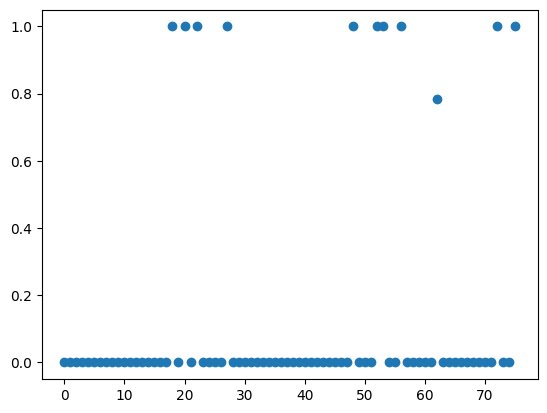

Count near zero: 65, near one 10
Objects with middle values: ['2025 MV31']


In [14]:
# Pull out G12*
g12star = {}
for row in our_fourier:
    k = row.selected_k[0].as_py()
    best_row = pickle.loads(row.intermediate_result[0])[k-2]
    g12star[row.object_id[0].as_py()] = best_row.values[0].as_py()[1]
plt.figure()
plt.scatter(range(len(g12star)), list(g12star.values()))
plt.show()
g12array = np.array(list(g12star.values()))
print(f"Count near zero: {sum(g12array < 0.01)}, near one {sum(g12array>0.99)}")
print(f"Objects with middle values: {[k for k,v in g12star.items() if v > 0.01 and v < 0.99]}")

76 76


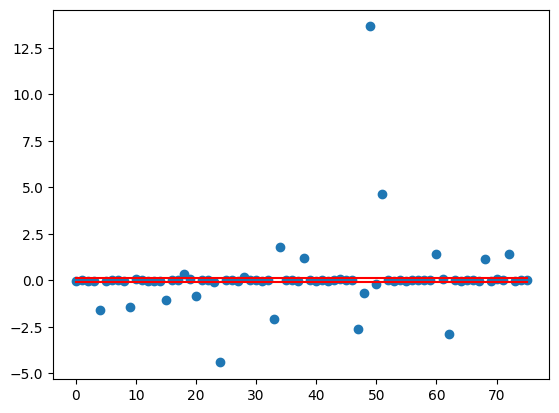

Really bad periods: {'2025 MP71': 13.649985639018828}


In [15]:
print(len(our_fourier), len(paper_periods))
plt.figure()
plt.scatter(range(len(deltas_periods)), list(deltas_periods.values()))
plt.plot(range(len(deltas_periods)), [0.1]*len(deltas_periods), color='r')
plt.plot(range(len(deltas_periods)), [-0.1]*len(deltas_periods), color='r')
plt.show()
bad_fits = {k:v for k, v in deltas_periods.items() if abs(v)>5}
print(f"Really bad periods: {bad_fits}")

{}


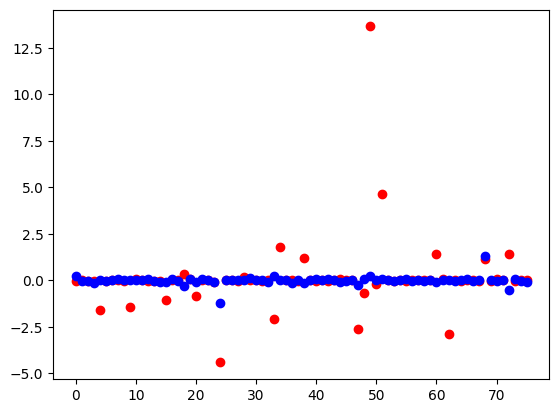

In [16]:
print({k:v for k,v in deltas_elongations.items() if v>10})
# del deltas_periods['2025 MP71']
# del deltas_elongations['2025 MP71']
plt.figure()
plt.scatter(range(len(deltas_periods)), list(deltas_periods.values()), c='r')
plt.scatter(range(len(deltas_elongations)), list(deltas_elongations.values()), c='b')
plt.show()


With matching input data sizes 29


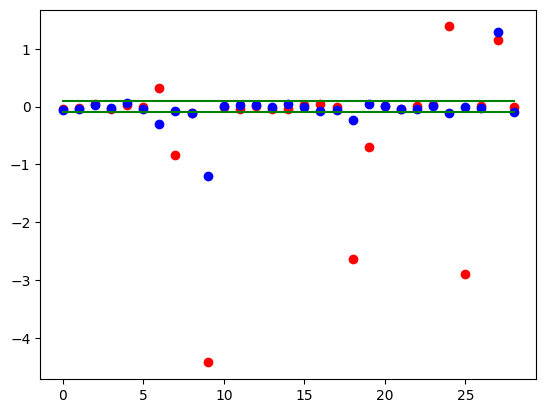

In [17]:
matching_periods = {k: v for k, v in deltas_periods.items() if k not in wrong_data_counts}
matching_elongations = {k: v for k, v in deltas_elongations.items() if k not in wrong_data_counts}
print(f"With matching input data sizes {len(matching_periods)}")
plt.figure()
plt.scatter(range(len(matching_periods)), list(matching_periods.values()), c='r')
plt.scatter(range(len(matching_elongations)), list(matching_elongations.values()), c='b')
plt.plot(range(len(matching_periods)), [0.1]*len(matching_periods), color='g')
plt.plot(range(len(matching_periods)), [-0.1]*len(matching_periods), color='g')
plt.show()


In [18]:
actually_bad = {v for v in wrong_data_counts if abs(deltas_periods[v]) > 0.5 or abs(deltas_elongations[v] > 0.2)}
print(f"Total number with wrong data counts {len(wrong_data_counts)}, actually bad {len(actually_bad)}")

for key in actually_bad:
    compare_our_fourier(key, kind=-1, force_query=False)

Total number with wrong data counts 47, actually bad 10
Read total 76 records
For 2025 MH69 F/LSM, arc 12.040803900468745 vs 12
Num observations 280 vs 314
Selected k=2, used observations 278
Period:   6.717215608953858 vs 7.8 / 6.7
Amplitude 0.6323062237078193 vs 0.7 / 0.7
G-R       0.6239286916452471 vs 0.63 / 0.63
G-I       0.7994350148110989 vs 0.93 / 0.81
R-I       0.1755063231658518 vs 0.3 / 0.18
Elongation 1.5795742135683333 vs 1.7
Magnitudes [20.250409293246122, 19.450974278435023, 19.626480601600875, 0.0], c1,c2,G12 [1000000.0, 1.223286511224267e-07]
Read total 76 records
For 2025 MA19 F/LSM, arc 9.03377790509694 vs 9
Num observations 429 vs 447
Selected k=6, used observations 428
Period:   8.871315843117992 vs 8.9 / 8.9
Amplitude 1.1282739936645925 vs 1.0 / 0.7
G-R       0.42981769994178975 vs 0.46 / 0.44
G-I       0.542113491778764 vs 0.55 / 0.49
R-I       0.11229579183697425 vs 0.08 / 0.05
Elongation 2.3115039595815223 vs 2.1
Magnitudes [18.978841140685482, 18.4367276489067

## The Multiband Lomb–Scargle Approach

In [19]:
from gatspy.periodic import LombScargleMultiband

def run_lsm(object_id):
    selection, obstime, _otime, _mag = subset_data(object_id, all_data)
    from_paper = PAPER_TABLE2.apply_mask(pc.equal(PAPER_TABLE2.designation, object_id))
    mag_v = from_paper.h_mag[0].as_py()
    mag = selection["mag"].cast('float').to_numpy()
    # subtract MPC-predicted v-band magnitude
    mag = mag - mag_v
    print("Mag_v", mag_v)
    # normalize by median
    print(f"Median for normalization {np.median(mag)}")
    # mag = mag / np.median(mag)    
    # TODO remove outliers more than 3 standard deviations away
    print(f"Obj {object_id}, v-mag {mag_v}, count {len(selection)}")
    # print(mag)

    # dense, uniform grid search for the best periodic signal with a
    # range between 0.00065 days (0.936 minutes) and 3 days (72 hr)
    # p_min = 0.5 / 24  # 0.00065
    # p_max = 2.0 / 24  # 3
    p_min = 0.00065
    p_max = 3
    n_periods = int(( (1/p_min - 1/p_max)*(np.max(obstime) - np.min(obstime)) ) * 100)
    print(f"Num periods {n_periods}")

    model = LombScargleMultiband(Nterms_base = 2, Nterms_band = 0)
    # t : array_like, one-dimensional
    #     sequence of observation times
    # y : array_like, one-dimensional
    #     sequence of observed values
    # dy : float or array_like (optional)
    #     errors on observed values
    # filts : array_like (optional)
    #     The array specifying the filter/bandpass for each observation.
    dmag = selection["rmsmag"].cast('float').to_numpy()
    filters = selection["band"]
    # print(f"Types {type(dmag)} {type(dmag[0])}; {type(filters)} {type(filters[0])}")
    model.ﬁt(obstime, mag, dmag, ﬁlters)
    # Compute power at the following periods
    periods = np.linspace(p_min, p_max, n_periods) # periods in days
    power = model.periodogram(periods)
    return periods, power, p_min, p_max, n_periods, obstime, mag, dmag, filters, model


# Num observations 192 vs 192
# Selected k=2, used observations 187
# Period:   0.947183565225426 vs 0.9 / 0.9
# Amplitude 0.5323015935928634 vs 0.5 / 0.6
# G-R       0.579653777704273 vs 0.58 / 0.59
# G-I       0.8040004686242384 vs 0.76 / 0.75
# R-I       0.2243466909199654 vs 0.18 / 0.16
# Elongation 1.4259207155455589 vs 1.4
# Magnitudes [22.456031827099753, 21.652031358475515, 21.87637804939548, 0.0], c1,c2,G12 [1000000.0, 4.090512068900097e-08]
me68_periods, me68_power, m68_pmin, m68_pmax, m68_nump, m68_obstime, m68_mag, m68_dmag, m68_filters, m68_model = run_lsm("2025 ME68")

For object 2025 ME68: num obs 192, arc length 12.04134250000061
Mean mag in r-band 23.510643685001067, delta mag in r-band 1.0060005187988281
Counts per band: g 63, i 42, r 87, u 0
Mag_v 21.2
Median for normalization 2.422999382019043
Obj 2025 ME68, v-mag 21.2, count 192
Num periods 1852112


In [20]:
m68_peak_idx  = np.argmax(me68_power)
m68_period = me68_periods[m68_peak_idx]
print(f"Best period={m68_period} days = {m68_period * 24} h")
params = (m68_model._best_params(2 * np.pi / m68_period))
print(f"All params {params}")
m68_base_offset = params[0]
m68_color_offsets = params[-3:]
r_color_off = params[-3]
g_color_off = params[-2]
i_color_off = params[-1]

print(r_color_off, g_color_off, i_color_off)
print("Model colors", m68_model.unique_filts_)
print("Y mean by filter", m68_model.ymean_by_filt_)
g_color = m68_model.ymean_by_filt_[0]
r_color = m68_model.ymean_by_filt_[2]
i_color = m68_model.ymean_by_filt_[1]
print("Deltas between means", g_color - r_color, g_color - i_color, r_color - i_color)
# print(r_color, g_color, i_color)

# print(g_color - r_color + (g_color_off - r_color_off))

med = 2.422999382019043
# print(f"Delta colors {(m68_color_offsets[0]-m68_color_offsets[1])*med} {m68_color_offsets[0]-m68_color_offsets[2]} {m68_color_offsets[1]-m68_color_offsets[2]}")

r_band = m68_model.predict(m68_obstime, ['r'], m68_period)
i_band = m68_model.predict(m68_obstime, ['i'], m68_period)
g_band = m68_model.predict(m68_obstime, ['g'], m68_period)
g_color = np.average(g_band)
r_color = np.average(r_band)
i_color = np.average(i_band)

# Paper has them 0.59, 0.75, 0.16
print(g_color - r_color, g_color - i_color, r_color - i_color)


Best period=0.039469173823815096 days = 0.9472601717715623 h
All params [ 0.11079711 -0.04701825  0.04982715 -0.13446516 -0.22698683  0.00408147
 -0.00579667  0.0017152 ]
0.004081467221941696 -0.0057966682534146274 0.0017152010338035986
Model colors ['g' 'i' 'r']
Y mean by filter [2.7751455 1.9527568 2.238825 ]
Deltas between means 0.53632045 0.82238877 0.28606832
0.5386867141098914 0.8322669036714625 0.29358018956157106


In [21]:
def lsm_ampl(params, period_days):
    # period_days = 1 / freq
    freq = 1 / period_days
    sample = np.linspace(0, 2*period_days, num=1000)
    base = 2*np.pi*freq*sample
    G = np.zeros(len(sample))
    # assert len(values) == 2 + k*2 + 4
    for j in range(2):
        arg = base * (j + 1)
        G += params[1+2*j]   * np.cos(arg)
        G += params[1+2*j+1] * np.sin(arg)
    return np.max(G) - np.min(G)
print(lsm_ampl(params, m68_period))

0.6125771576860619


Expected p=0.9 h = 0.03945833333333333 days; p_min=0.00065, p_max=3
peak at index 23971 for 0.039469173823815096, value 0.5281157527991666
Step 1.6194223780324106e-06
At goal idx=23964, period=0.03945783786716887 value 0.4732182837247691


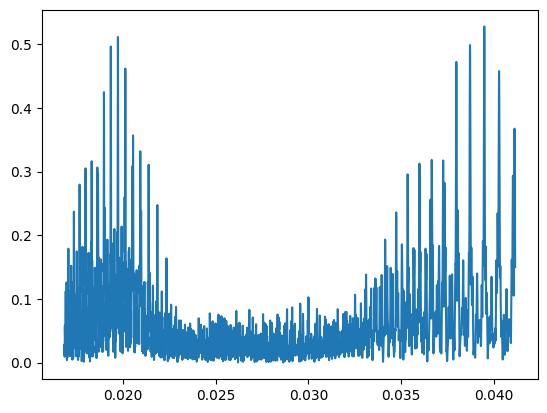

In [22]:
m68_peak  = np.argmax(me68_power)
expected_p = 0.947/24
print(f"Expected p=0.9 h = {expected_p} days; p_min={m68_pmin}, p_max={m68_pmax}")
print(f"peak at index {m68_peak} for {me68_periods[m68_peak]}, value {me68_power[m68_peak]}")
step = me68_periods[1] - me68_periods[0]
print(f"Step {step}")
goal_idx = int((expected_p - m68_pmin) / step)
print(f"At goal idx={goal_idx}, period={me68_periods[goal_idx]} value {me68_power[goal_idx]}")
plt.figure()
# plt.plot(me68_periods, me68_power)
plt.plot(me68_periods[10000:25000], me68_power[10000:25000])
plt.show()

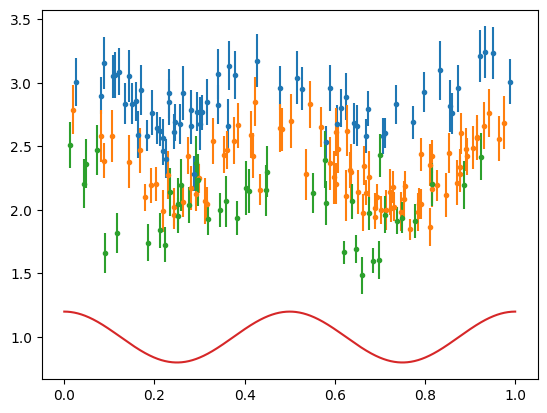

In [23]:
phase = (m68_obstime.to_numpy() / expected_p) % 1
phasefit = np.linspace(0, 1, 1000)
tfit = expected_p * phasefit

masks = [(m68_filters.to_numpy() == band) for band in 'gri']

plt.figure()
# print(m68_obstime.to_numpy().shape)
# print((m68_obstime.to_numpy() / expected_p).shape)
times = (m68_obstime.to_numpy() / expected_p) % 1
for band, mask in zip('gri', masks):
    # print(mask)
    # print(type(mask), type(m68_obstime.to_numpy()[mask]))
    ttt = times[mask]
    # print("TTT", ttt)
    # ttt = ttt.reshape(-1)
    # print(type(ttt), ttt.shape, type(m68_mag[mask]), type(m68_dmag[mask]))
    # ttt = [i for i in range(10)]
    mags = m68_mag[mask]
    # mags = [1] * len(ttt)
    dmags = m68_dmag[mask]
    # dmags = [0.1] * len(ttt)
    plt.errorbar(ttt, mags, dmags, fmt='.', label=band)


#tfit1 = np.linspace(5 * expected_p, 15 * expected_p, 30)
#filtsfit = np.array(['i', 'r', 'g'])[:, None] # np.arange(3)[:, None]
# prediction = m68_model.predict(tfit1, filtsfit, period=expected_p)
#prediction = m68_model.predict(m68_obstime, filtsfit, period=expected_p)
# print(prediction)


#plt.errorbar(phase, m68_mag, m68_dmag, fmt='o', color='#AAAAAA')
plt.plot(phasefit, np.cos(4*np.pi*phasefit)*0.2+1.0)
# plt.plot(m68_obstime, prediction[0])
# plt.plot(m68_obstime, m68_model.predict(m68_obstime, filts = m68_filters.to_numpy(), period=expected_p))
plt.show()

For object 2025 ME68: num obs 192, arc length 12.04134250000061
Mean mag in r-band 23.510643685001067, delta mag in r-band 1.0060005187988281
Counts per band: g 63, i 42, r 87, u 0
Obj 2025 ME68, v-mag 21.2, count 192
Num periods 1852112


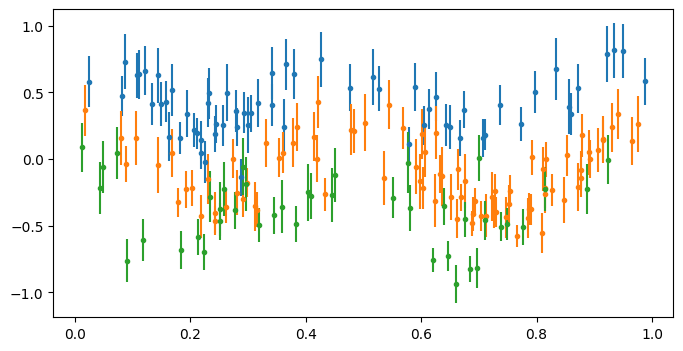

In [24]:
def run_lsm2(object_id):
    selection, obstime, _otime, _mag = subset_data(object_id, all_data)
    from_paper = PAPER_TABLE2.apply_mask(pc.equal(PAPER_TABLE2.designation, object_id))
    mag_v = from_paper.h_mag[0].as_py()
    mag = selection["mag"].cast('float').to_numpy()
    # subtract MPC-predicted v-band magnitude
    mag = mag - mag_v
    # normalize by median
    mag = mag - np.median(mag)
    # TODO remove outliers more than 3 standard deviations away
    print(f"Obj {object_id}, v-mag {mag_v}, count {len(selection)}")
    # print(mag)

    # dense, uniform grid search for the best periodic signal with a
    # range between 0.00065 days (0.936 minutes) and 3 days (72 hr)
    # p_min = 0.5 / 24  # 0.00065
    # p_max = 2.0 / 24  # 3
    p_min = 0.00065
    p_max = 3
    n_periods = int(( (1/p_min - 1/p_max)*(np.max(obstime) - np.min(obstime)) ) * 100)
    print(f"Num periods {n_periods}")

    # model = LombScargleMultiband(Nterms_base = 1, Nterms_band = 0)
    # t : array_like, one-dimensional
    #     sequence of observation times
    # y : array_like, one-dimensional
    #     sequence of observed values
    # dy : float or array_like (optional)
    #     errors on observed values
    # filts : array_like (optional)
    #     The array specifying the filter/bandpass for each observation.
    dmag = selection["rmsmag"].cast('float').to_numpy()
    filters = selection["band"]
    # print(f"Types {type(dmag)} {type(dmag[0])}; {type(filters)} {type(filters[0])}")
    # model.ﬁt(obstime, mag, dmag, ﬁlters)
    # Compute power at the following periods
    # periods = np.linspace(p_min, p_max, n_periods) # periods in days
    # power = model.periodogram(periods)
    # return periods, power, p_min, p_max, n_periods, obstime, mag, dmag, filters, model

    expected_p = 0.947/24
    # phase = (obstime.to_numpy() / expected_p) % 1
    # phasefit = np.linspace(0, 1, 1000)
    # tfit = expected_p * phasefit
    times = (obstime.to_numpy() / expected_p) % 1
    masks = [(filters.to_numpy() == band) for band in 'gri']

    plt.figure(figsize=(8, 4))
    for band, mask in zip('gri', masks):
        plt.errorbar(times[mask], mag[mask], dmag[mask], fmt='.', label=band)

    plt.show()

me68_all = run_lsm2("2025 ME68")